# Data Driven Models: Linear Regression Diagnostics

### Last Class
- Linear regression

### Goals for Today
- Discuss the assumptions of linear regression and the procedure for Linear Regression Diagnostics
- Curate a list of numerical methods/plots to verify assumptions
- Verify the linear regression assumptions for mathematical models

### Pre-Lecture Activities

- Read the Linear regression assumptions overview below.

### Linear regression assumptions
Assumptions:
A linear regression assumes that a linear relationship exists between $\vec{x}$ and $\vec{y}$, and that the covariates are linearly independent of each other. The independent variables are also assumed to be measured without error, which is almost never true in practice.  In fact, measurement error is hard to quantify and measure, and can cause bias in the estimate. 

In addition, linear regression has 4 assumptions on the error $\vec{\epsilon}$ of the relationship.
1. The average value of the error is 0: i.e., $\mathbb{E}(\epsilon_i) = 0$ for all $i$
2. The variance of the error is constant: i.e., $Var(\epsilon_i) = \sigma^2$ for all $i$.  This is called homoscedasticity or homoskedasticity. Note here that $\sigma^2$ is unknown.
3. The error $\vec{\epsilon}$ is a random sample from the normal distribution of zero mean and variance $\sigma^2$.
4. The error is independent for each $\epsilon_i$ for all $i$.

For most of the error assumptions, as long as we have enough data, the Central Limit Theorem will force our errors to be normally distributed, so point 4 is often satisfied if we have a large enough data set (remember that "large" here is subjective, but usually means over 500 data points).

### Residual

The residual is the vertical distance between the actual $\vec{y}$ and the estimate $\hat{\vec{y}}$ from the linear regression, and is denoted $\vec{e} = \vec{y} - \hat{\vec{y}}.$  We can think of these as estimates of $\vec{\epsilon}$.

### How can we check if the assumptions are satisfied?
There are some plots that we can generate to check to see if the assumptions of linear regression are satisfied.  Here, we will use the `statsmodels.api` package to run the linear regression as `regression = sm.OLS(Y, X).fit()`.

1. Assumption: average value of the error is zero.
    - Produce a Residual - Covariate plot
        - Plots the residual against each covariate in the model
        - Want to see Random Scatter about horizontal axis
            - ideally there should be roughly an equal number of points above and below the residual = 0 line
                - equally likely to over- and underestimate
            - want to ensure that the covariate is not correlated with the residual 
            - if pattern, improvements should be made
       - In python, we can produce this plot using `import statsmodels.api as sm` and calling `sm.graphics.plot_regress_exog(regression,variable)`
    - Produce a partial regression plot
        - plots the residual of the the regression of $Y$ against all covariates except $X_i$ against the residuals of the regression of $X_i$ against all the other covariates
            - we want to interpret this as the residuals of $X_i$ a after all other predictors are accounted for vs the residuals of $Y$ after all other predictors (except $X_i$) are accounted for
            - mean of residuals for both of these should be zeor, so the line plotted should go through (0,0)
        - shows possible relationship between covariates and the response variable
        - want to see a linear trend with $\hat{\beta}_i$
            - idea here is that the term associated with $X_i$ contributes *linearly* to the effect in $Y$
        - In python, these will also be outputted when `sm.graphics.plot_regress_exog(regression,variable)` is used, but we can produce all of the partial regression plots by using `sm.graphics.plot_partregress_grid(regression)`
2. Assumption: Variance is constant
    - Produce a residual - fitted plot
        - plot of the residual against the fitted value (i.e., the $\hat{y}$ values)
        - want to see Random Scatter about horizontal axis
            - if pattern, indication of a violation of one or more assumptions
            - idea here is that the residuals estimates the error and so plotting againsted the fitted $y$ values should show us points that, on average, are zero but have a constant variation (so random scatter above and below the horizontal zero line)
    - In python, this can be produced pulling the residuals and fitted values out of the regression using  `fitted_y = regression.fittedvalues` and `residuals = regression.resid` and then plotting the fitted_y on the horizontal axis and residual on the vertical axis.  We often will also add a horizontal dashed line at $y=0.$
3. Assumption: Errors are normally distributed
    - Produce a Normal QQ plot of residuals
        - compares residual to what we woud expect to if we obtained a sample of size $n$ from a standard normal
        - if residuals are normally distributed, they should be approximately equal to the sample from the standard normal
        - want to see that points lie along the line $y=x$
        - small sample sizes often yield normal QQ plots which deviate from linearity.... usually want $n \geq 20$ to produce QQ plots that are stable enough to be interpreted
    - In python, we can use `sm.qqplot(residuals,fit=True, line="45")`.
4. Assumption: Errors are independent
    - When observations are collected over time (i.e., time series), we would like to check whether observations are correlated over time
    - Produce a residual - index plot
        - plot of residual vs time order
        - Want to see random scatter
    - We will not be dealing with time series data in this course, though there is an example of this type of plot in the course notes on GitHub.  To produce the plot in python, plot the residual vs time for each data point.

## Clicker Questions

1. Linear regression requires that in the inputs (covariates or features) are linearly independent.

   A. True.

   B. False.

   C. Not Sure.

2. In practice, the inputs (covariates or features) for a linear regression are *always* linearly independent.

   A. True.

   B. False.

   C. Not Sure.

3. In the QQ plot, we want to see:

   A. Random scatter about the line $y=x$.

   B. Random scatter about the line $y=-x$.

   C. Points lie on the line $y=x$.

   D. Points lie on the line $y=-x$.

4. In the residual vs covariate plot, we want to see random scatter because:

   A. The error is not correlated with the covariate.

   B. The error is correlated with the covariate.

   C. The covariate is linearly dependent on other covariates in the model.

   D. The covariate is linearly independent on other covairats in the model.

In [1]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy.stats import poisson
from scipy.stats import norm
%matplotlib inline

print("packages imported")

packages imported


### MLB Data

Let's revisit the MLB data and plot the diagnostic plots for when we have covariates runs, dbls, and strikeouts, with response variable batavg.

Use the `statsmodels.api` package to produce the linear regression and the diagnostic plots.

In [2]:
# We need to tell statsmodels to include a constant beta_0
#import data 
mlb_data = pd.read_csv('baseball.csv')

mlb = pd.DataFrame(mlb_data)

X = mlb[['runs','dbls','strikeouts']]
Y = mlb['batavg']

X = sm.add_constant(X)
 
#run regression    
reg_1 = sm.OLS(Y, X).fit()
 
summary_table = reg_1.summary()
print(summary_table)

                            OLS Regression Results                            
Dep. Variable:                 batavg   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     77.47
Date:                Thu, 07 Nov 2024   Prob (F-statistic):           6.17e-17
Time:                        21:00:50   Log-Likelihood:                 119.90
No. Observations:                  45   AIC:                            -231.8
Df Residuals:                      41   BIC:                            -224.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1694      0.015     11.188      0.0

#### Assumption: average value of the error is zero.

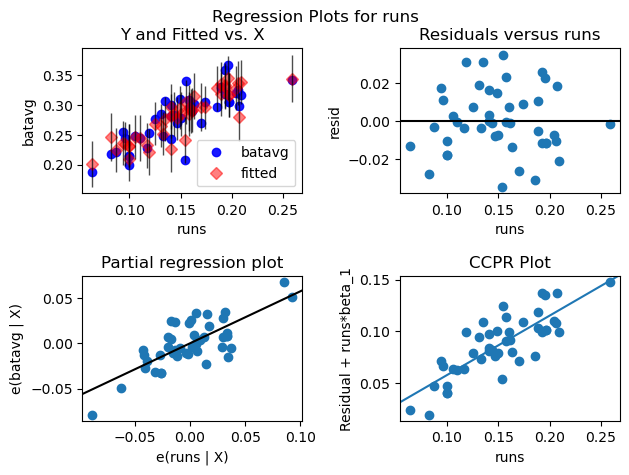

In [3]:
sm.graphics.plot_regress_exog(reg_1,"runs")
plt.show()

Note: this plot also outputs Y and Fitted vs X and a CCPR plot.  We will not be using these in Math 360, so you can ignore them. 

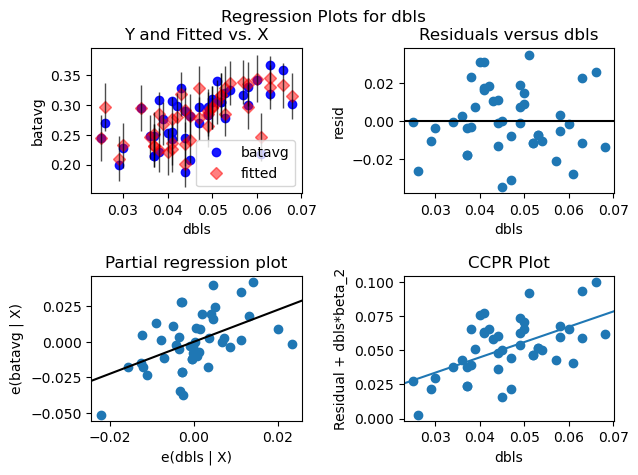

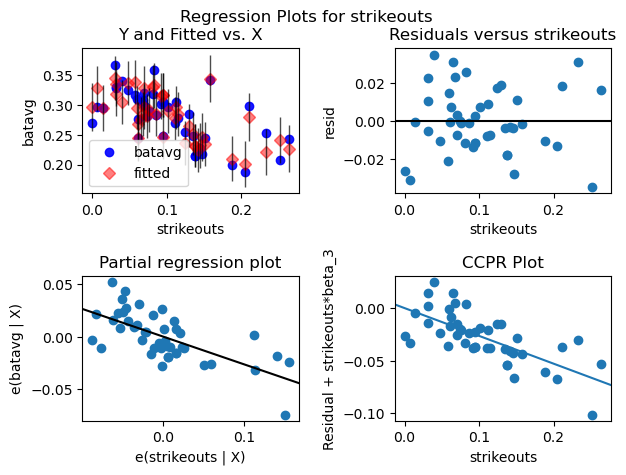

In [4]:
sm.graphics.plot_regress_exog(reg_1,"dbls")
plt.show()

sm.graphics.plot_regress_exog(reg_1,"strikeouts")
plt.show()

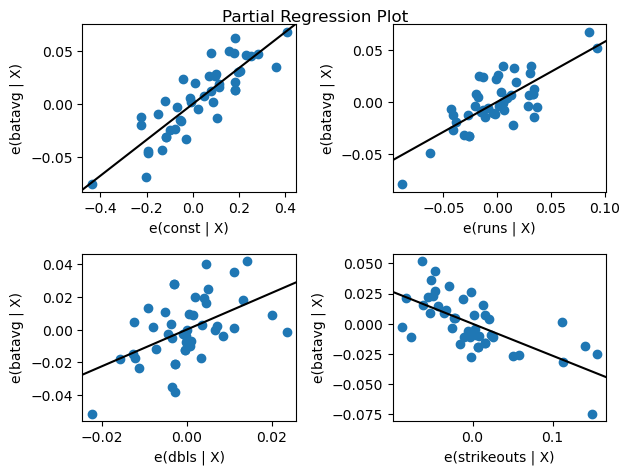

In [5]:
sm.graphics.plot_partregress_grid(reg_1)
plt.show()

#### Assumption: Variance is constant

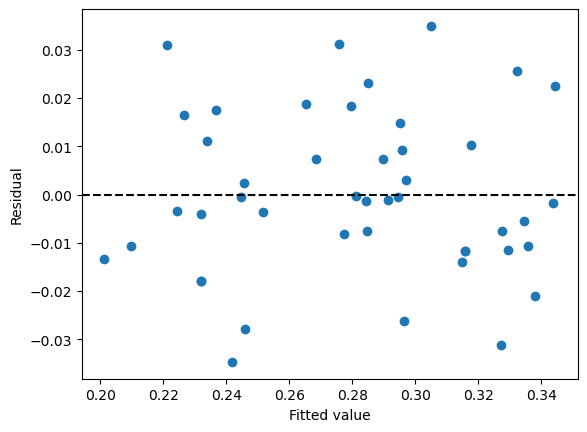

In [6]:
fitted_y = reg_1.fittedvalues

residuals = reg_1.resid

plt.scatter(fitted_y,residuals)
plt.axhline(y=0,color='k',linestyle = '--')
plt.xlabel('Fitted value')
plt.ylabel('Residual')
plt.show()

#### Assumption: Errors are normally distributed

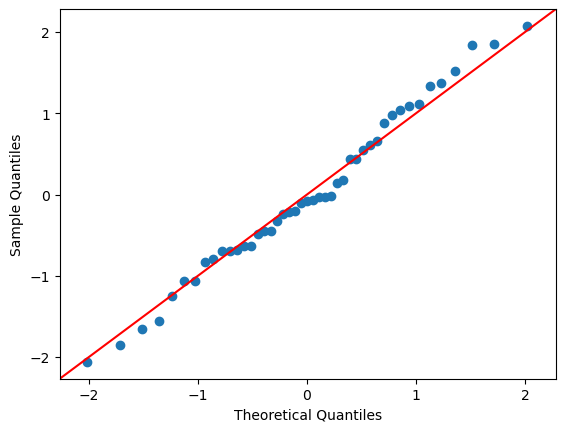

In [7]:
sm.qqplot(residuals, fit=True, line="45")
plt.show()

#### Assumption: Errors are independent

Data is not time series data -- cannot run the residual vs index plot.

Diagnostic plots here look okay.  We can say that we do not see any violations in the linear regression assumptions. 

### Example - MLB 2
Rerun the mlb data regression, but include the inputs for trpls and homeruns as covariates as well.  Output the relevant diagnostic plots.  Does your group have any concerns about the assumptions of the linear regression model?

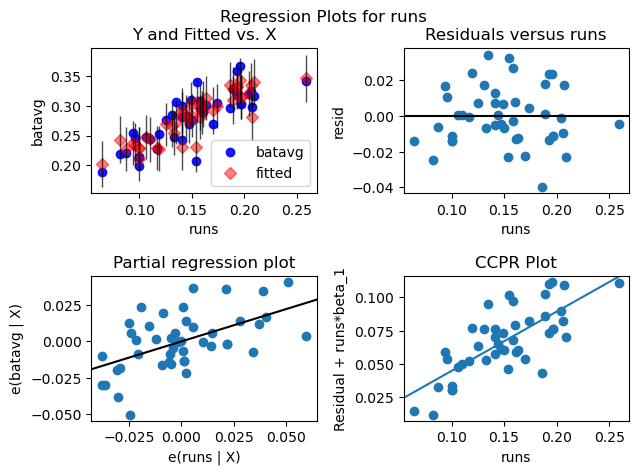

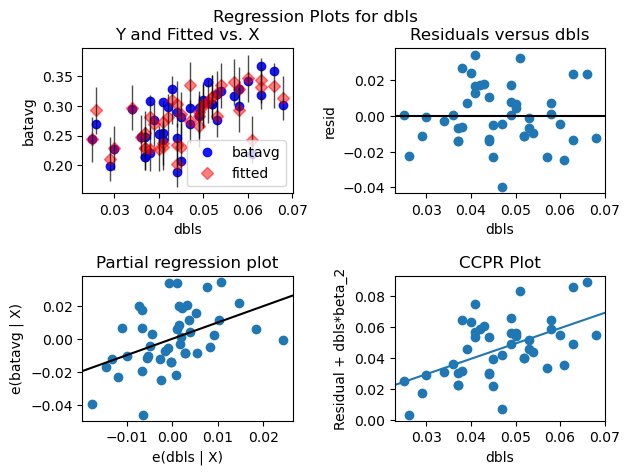

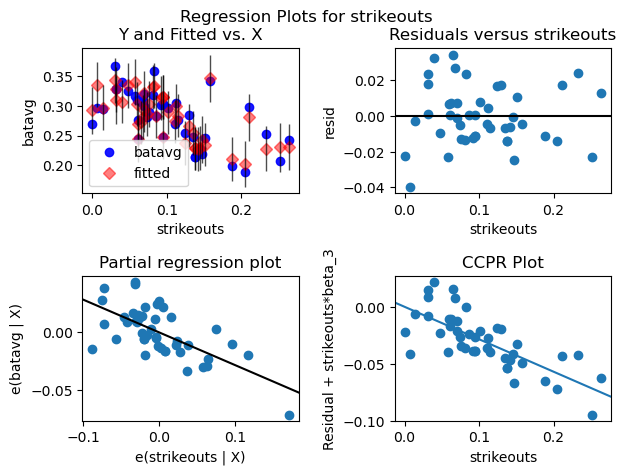

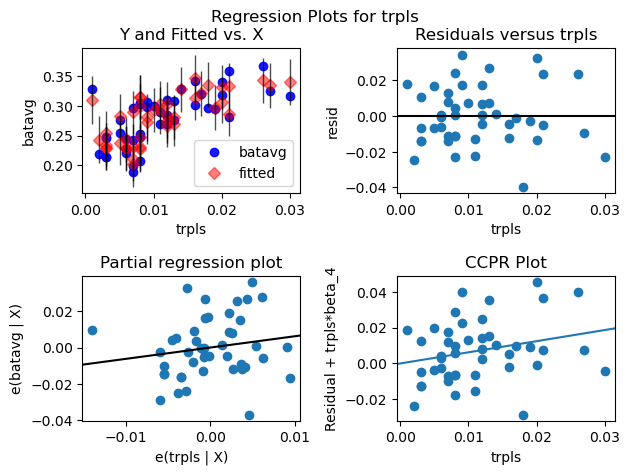

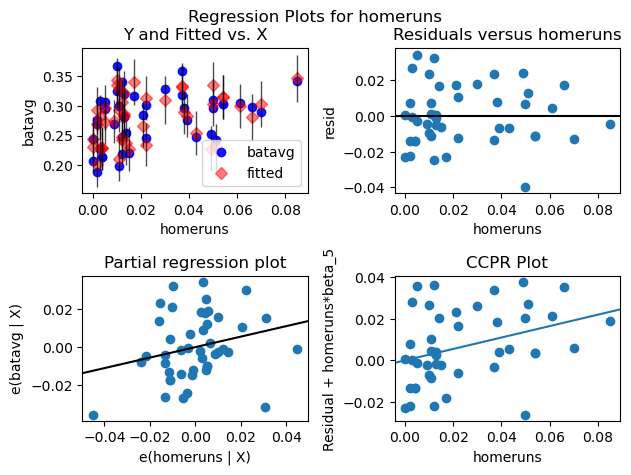

In [8]:
X1 = mlb[['runs','dbls','strikeouts','trpls','homeruns']]
Y1 = mlb['batavg']


# We need to tell statsmodels to include a constant beta_0
X1 = sm.add_constant(X1)
 
#run regression    
reg_2 = sm.OLS(Y1, X1).fit()

## Assumption: Average value error is zero
# residual covariate plots
sm.graphics.plot_regress_exog(reg_2,"runs")
sm.graphics.plot_regress_exog(reg_2,"dbls")
sm.graphics.plot_regress_exog(reg_2,"strikeouts")
sm.graphics.plot_regress_exog(reg_2,"trpls")
sm.graphics.plot_regress_exog(reg_2,"homeruns")
plt.show()

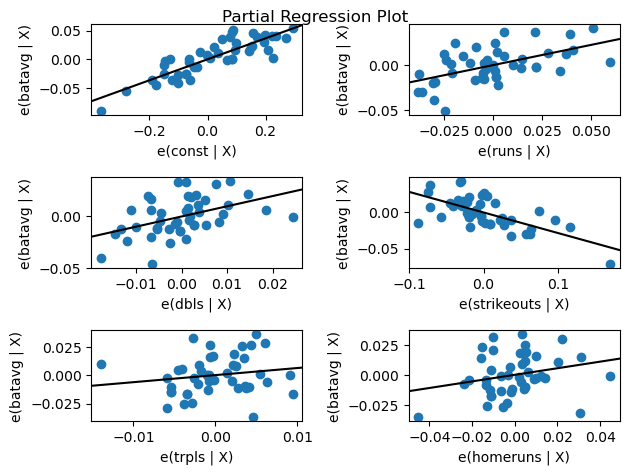

In [9]:
## partial regression plots in grid together
sm.graphics.plot_partregress_grid(reg_2)
plt.show()

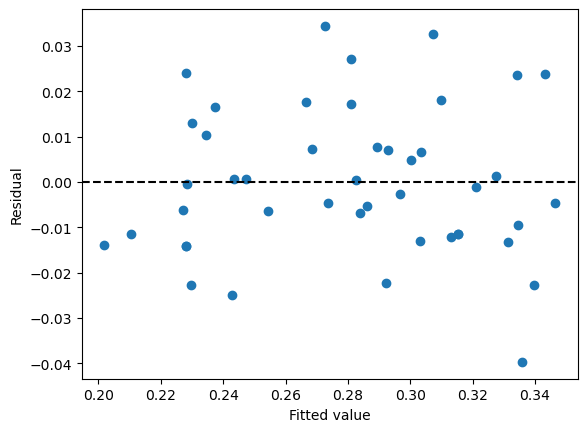

In [10]:
## Assumption: Variance constant
#pull out fitted values from regression
fitted_y1 = reg_2.fittedvalues
residuals1 = reg_2.resid

plt.scatter(fitted_y1,residuals1)
plt.axhline(y = 0, color = 'k', linestyle = '--')
plt.xlabel('Fitted value')
plt.ylabel('Residual')
plt.show()

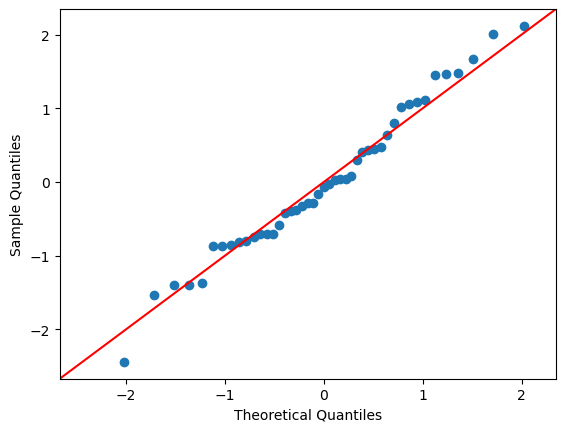

In [11]:
## Assumption: Error normally distributed
## pull out residuals from the model fitting
residuals1 = reg_2.resid

sm.qqplot(residuals1,fit=True, line="45")
plt.show()

#### Assumption: Errors are independent

Data is not time series data -- cannot run the residual vs index plot.

The residuals vs runs plot looks the most suspicious, but could be considered OK depending on the provided justification. Overall, the diagnostic plots here look okay, and we could say that we do not see any violations in the linear regression assumptions. 

## Key points

#### Average value of error is zero

1. Residual-Covariate plot.
    - want to see random scatter, as this means that the covariate is not correlated with the residual
    - typically are also looking for an even distribution above and below zero
        - i.e., it is equally probable that the there is over- and under-estimation.

2. Partial regression plot.
    - Idea here is to "partial out"/remove the effect of other covariates to see how each *individually* affects the response $Y$.
    - Plot here is plotting the residuals of $Y$ when $X_i$ is **not** included in the regression vs the residuals of $X_i$ when the other covariates are accounted for.
    - Mean of the residuals should be $0$, so the line should go throuh $(0,0)$.
    - Want to see a linear trend, as this indicates that $X_i$ accounts for a linear effect in the response $Y$.  Note that this does **not** mean we can say from the partial regression plot what $X_i$'s correlation with $Y$ is or how $X_i$ should enter in to the linear regression.

#### Variance is constant

1. Residual vs fitted plot
    - Want to see random scatter.
    - Regression is $Y = \beta_0 + \beta_1 X_1 + \dots + \beta_p X_p + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0,\sigma_{\varepsilon}^2)$.
    - The fitted $Y$ values are $\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \dots + \hat{\beta}_p X_p,$ where $\hat{\beta}_i$ are the estimates of the regression coefficients obtained from the normal equations (i.e., running the OLS linear regression).
    - Here, $\sigma_{\varepsilon}^2$ is unknown, but not random.  So plotting the residuals which estimate $\varepsilon$ against the fitted $\hat{Y}$ values should so how points that, on average, are zero, but have constant variation.
        - That is, we should see random scatter with approximately equal points above/below the horizontal zero. 

#### Errors are normally distributed

1. Normal QQ plot of the residuals
    - This is plotting the *quartiles* of the residual against the quartiles from a standard normal ($\mathcal{N}(0,1)$).
    - If the errors are indeed normally distirbuted, then their quartiles should align, and, hence, why we would like to see the points sit on the line $y=x$.

**Remember** Real data will not look perfect.  There will be some grey areas where plots may indicate a violation or not.  Here, we will be looking to say one way or the other and provide a justification for why we are making the claim.  